# 02 — Index numbers, LMDI, PVM, shift–share, and SDA

**Graduate course: Decomposition Analysis in Python**

## Learning objectives

- Compare Laspeyres, Fisher, and logarithmic-mean allocations.
- Implement exact additive LMDI.
- Understand PVM and SDA as decompositions of identities.

## Roadmap and notation

### Guiding question

How can a change in a total generated by several multiplicative factors be allocated without leaving an unexplained residual?

### Prerequisites

Products, logarithms, and before/after comparisons. No calculus is required to run the examples; the Divisia differential is included to explain the origin of LMDI.

### Symbols

- $i$: product, channel, sector, or other component.
- $Q_{it}$: activity or quantity; $I_{it}$: intensity or rate.
- $E_{it}=Q_{it}I_{it}$: component total.
- $L(a,b)$: logarithmic mean, a symmetric weight between positive $a$ and $b$.
- $p_{it},q_{it}$: price and quantity in PVM/index-number notation.

The notebook treats LMDI and PVM separately because both decompose identities but allocate interactions differently.

## Multiplicative identities

If emissions $E=\sum_i Q_i I_i$, the additive LMDI uses the logarithmic mean $L(a,b)=(a-b)/(\log a-\log b)$:
$$\Delta E_Q=\sum_iL(E_{i1},E_{i0})\log(Q_{i1}/Q_{i0}),\quad
\Delta E_I=\sum_iL(E_{i1},E_{i0})\log(I_{i1}/I_{i0}).$$
It is exact for positive values and has no residual. PVM applies the same identity logic to revenue $\sum_i p_iq_i$, but common business conventions allocate the interaction differently. Laspeyres uses base weights; Fisher is the geometric mean of Laspeyres and Paasche indexes. Shift–share partitions regional change into national, industry-mix, and regional-competitive terms. SDA applies polar/average or all-permutation rules to input–output identities.

## Index-number formulas and exactness

For prices $p_t$ and quantities $q_t$, the Laspeyres and Paasche price indexes are

$$P_L=\frac{\sum_i p_{i1}q_{i0}}{\sum_i p_{i0}q_{i0}},\qquad
P_P=\frac{\sum_i p_{i1}q_{i1}}{\sum_i p_{i0}q_{i1}},$$

and Fisher's superlative index is $P_F=(P_LP_P)^{1/2}$. For a multiplicative identity $Y=\prod_k x_k$, the Divisia differential is

$$d\log Y=\sum_k \frac{\partial\log Y}{\partial\log x_k}d\log x_k.$$

LMDI replaces the continuous integral by logarithmic-mean weights and produces a perfect finite-change decomposition for positive data. PVM instead expands

$$\Delta(pq)=q_0\Delta p+p_0\Delta q+\Delta p\Delta q,$$

so the price–volume interaction must be reported or allocated by a declared rule.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from itertools import permutations, combinations
pd.options.display.float_format = '{:,.4f}'.format
plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)

In [2]:
x = pd.DataFrame({
    'product': ['A', 'B', 'C'],
    'q0': [100, 80, 50],
    'q1': [115, 70, 66],
    'i0': [2.0, 3.0, 5.0],
    'i1': [1.8, 3.4, 4.6],
})
x['E0'] = x.q0 * x.i0
x['E1'] = x.q1 * x.i1

def L(a,b):
    # Logarithmic mean, using its continuous value when a equals b.
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return np.where(np.isclose(a, b), a, (a - b) / (np.log(a) - np.log(b)))

log_weights = L(x.E1, x.E0)
x['activity'] = log_weights * np.log(x.q1 / x.q0)
x['intensity'] = log_weights * np.log(x.i1 / x.i0)

lmdi_summary = pd.Series({
    'observed': x.E1.sum() - x.E0.sum(),
    'activity': x.activity.sum(),
    'intensity': x.intensity.sum(),
    'residual': (x.E1 - x.E0 - x.activity - x.intensity).sum(),
})
x, lmdi_summary

(  product   q0   q1     i0     i1       E0       E1  activity  intensity
 0       A  100  115 2.0000 1.8000 200.0000 207.0000   28.4388   -21.4388
 1       B   80   70 3.0000 3.4000 240.0000 238.0000  -31.9138    29.9138
 2       C   50   66 5.0000 4.6000 250.0000 303.6000   76.6077   -23.0077,
 observed     58.6000
 activity     73.1327
 intensity   -14.5327
 residual      0.0000
 dtype: float64)

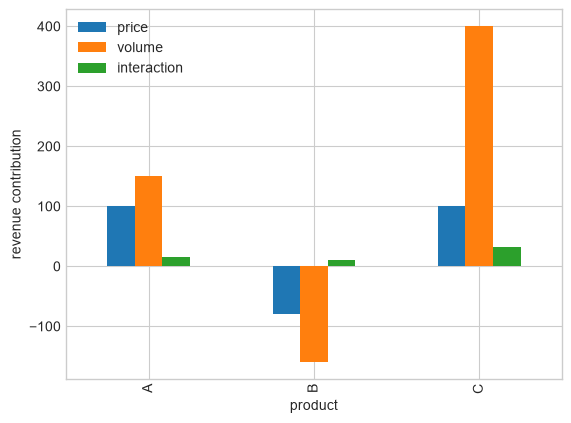

In [3]:
p0 = np.array([10., 16., 25.])
p1 = np.array([11., 15., 27.])
q0 = x.q0.to_numpy()
q1 = x.q1.to_numpy()

price = (p1 - p0) * q0
volume = p0 * (q1 - q0)
interaction = (p1 - p0) * (q1 - q0)

pvm = pd.DataFrame({
    'product': x['product'],
    'price': price,
    'volume': volume,
    'interaction': interaction,
}).set_index('product')
pvm.plot.bar()
plt.ylabel('revenue contribution')
plt.show()

## Reading the worked examples

The first table shows an observed total increase of 58.6. Activity contributes +73.13 while intensity contributes −14.53; these sum exactly to 58.6. Intensity therefore offsets part of the activity-driven increase. The zero residual is an algebraic property of LMDI for these positive data.

The PVM chart answers a different question. Its bars use base-period quantities and prices, while the interaction is shown separately. A large price bar is not a demand elasticity and does not estimate what quantity would have been under a different price.

## Growth-marketing case: revenue and paid acquisition

A useful driver identity is

$$\text{Revenue}=\text{Impressions}\times\text{CTR}\times\text{CVR}\times\text{AOV}.$$

LMDI can allocate the observed change across scale, click efficiency, conversion, and order value. A second identity,

$$\text{Profit}=\text{Revenue}-\text{Spend},\qquad
\text{Spend}=\text{Clicks}\times\text{CPC},$$

prevents a favorable revenue attribution from being mistaken for incremental profit. Use channel-level components, report zeros explicitly, and distinguish gross from incremental conversions.

In [4]:
# Growth funnel: exact LMDI allocation of revenue change
f0 = pd.Series({'impressions':1_000_000., 'ctr':.020, 'cvr':.040, 'aov':55.})
f1 = pd.Series({'impressions':1_150_000., 'ctr':.023, 'cvr':.037, 'aov':58.})
y0, y1 = f0.prod(), f1.prod()
weight = L(np.array([y1]), np.array([y0]))[0]
funnel_contrib = weight * np.log(f1/f0)
pd.concat([funnel_contrib.rename('contribution'),
           (100*funnel_contrib/(y1-y0)).rename('share_pct')], axis=1).assign(
               total_change=y1-y0 if False else np.nan)

,contribution,share_pct,total_change
impressions,"7,003.5135",54.8792,NaN
ctr,"7,003.5135",54.8792,NaN
cvr,"-3,906.6766",-30.6125,NaN
aov,"2,661.3495",20.8542,NaN


## Limitations and robustness

- Standard LMDI requires positive values; zeros need documented limiting conventions and negative values can invalidate logs.
- Identity decompositions are sensitive to the chosen factorization: CTR×CVR and clicks×orders-per-click are algebraically related but tell different stories.
- Chained indexes reduce base-period staleness but introduce chain drift and revisions.
- PVM “mix” is often mislabeled: changing product shares, pure volume, and interaction should be separated.
- SDA is computationally expensive as determinants grow and inherits input–output measurement error.
- None of these methods corrects endogeneity, anticipatory behavior, ad auctions, or cross-channel substitution.

## What came next

**Diewert (1976)** formalized exact and superlative indexes, including Fisher's desirable approximation properties. For energy/environment identities, **Ang & Choi (1997)** introduced a refined logarithmic-mean Divisia method; **Ang (2005)** consolidated the preferred LMDI formulation, and **Ang (2015)** provided a practical guide. In structural decomposition, **Dietzenbacher & Los (1998)** showed why averaging polar forms or all paths matters when multiple determinants change.

## Takeaways and bridge to Notebook 03

1. LMDI gives an exact decomposition for positive multiplicative data.
2. PVM and index-number methods differ mainly in weighting and interaction allocation.
3. Factorization is a modeling choice, even when the identity is exact.
4. These are descriptive contributions, not elasticities or incrementality estimates.

Notebook 03 changes the target from an accounting total to a gap estimated from individual-level regressions.

### Exercise

Reallocate the PVM interaction 50/50 and compare rankings. Explain why both answers can be exact yet non-unique.

## Interpretation checklist

1. State the mathematical identity or estimand.
2. Verify exactness numerically.
3. Separate description, prediction, and causation.
4. Report reference population/path/order.
5. Quantify sampling uncertainty when inputs are estimated.

## References

- Diewert, W. E. (1976). Exact and superlative index numbers. *Journal of Econometrics*, 4, 115–145. https://doi.org/10.1016/0304-4076(76)90009-9
- Ang, B. W. (2005). The LMDI approach to decomposition analysis. *Energy Policy*, 33, 867–871. https://doi.org/10.1016/j.enpol.2003.10.010
- Dunn, E. S. (1960). A statistical and analytical technique for regional analysis. *Papers of the RSA*, 6, 97–112.
- Rose, A., & Casler, S. (1996). Input–output structural decomposition analysis. *Economic Systems Research*, 8, 33–62. https://doi.org/10.1080/09535319600000003
- Ang, B. W., & Choi, K.-H. (1997). Decomposition of aggregate energy and gas emission intensities for industry: A refined Divisia index method. *The Energy Journal*, 18(3), 59–73.
- Ang, B. W. (2015). LMDI decomposition approach: A guide for implementation. *Energy Policy*, 86, 233–238. https://doi.org/10.1016/j.enpol.2015.07.007
- Dietzenbacher, E., & Los, B. (1998). Structural decomposition techniques: Sense and sensitivity. *Economic Systems Research*, 10, 307–324. https://doi.org/10.1080/09535319800000023